# Setup Notebook

In [27]:
%run analysis__setup.ipynb

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using RUN_TO_ANALYSE = 41
The data has N = 1720320 rows and N = 119 columns.
Dropping N = 0 rows, keeping N = 1720320


## Prepare Data


In [28]:
# Filter out a single configuration to keep data manageable
df_agg = df_agg_full[
  (df_agg_full["sett_eval_fairness_grouping"] == "race-all") &
  (df_agg_full["sett_eval_exclude_subgroups"] == "keep-in-eval") &
  (df_agg_full["sett_eval_on_subset"] == "full")
][
  # Remove eval columns
  cols_non_eval + cols_performance + cols_fairness
].reset_index(drop = True)

df_agg.shape

(61440, 109)

# Calculate Variable Importance

## Use a Lasso Regression to estimate Importance of Settings

In [29]:
X = df_agg[cols_non_eval]
y = df_agg[main_fairness_metric]

### Main Effects of Settings Only (i.e. no interations)

In [30]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LassoCV

# Do preprocessing in a separate pipeline from model fitting
# (for eli5 to work)
preprocessor = make_pipeline(
    OneHotEncoder(),
).fit(X)
X_processed = preprocessor.transform(X)

lasso_reg = LassoCV(cv=5, random_state=0).fit(X_processed, y)

# Check whether it's predictive at all
lasso_reg.score(X_processed, y)


0.4724612418970293

Weights of importance:

In [31]:
import eli5
eli5.show_weights(lasso_reg, top=-1, feature_names = preprocessor.get_feature_names_out())


Weight?,Feature
+0.522,<BIAS>
+0.372,sett_stratify_split_target
+0.041,sett_cutoff_quantile_0.25
+0.027,sett_exclude_subgroups_keep-all
+0.026,sett_exclude_subgroups_drop-name_race_Some Other Race alone
+0.026,sett_exclude_features_none
+0.019,sett_exclude_features_sex
+0.012,sett_model_rf
+0.011,sett_preprocess_income_quantiles_3
+0.003,sett_preprocess_income_quantiles_4


### Including Interactions

In [32]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LassoCV

# Do preprocessing w/o a pipeline for eli5 to work
preprocessor = make_pipeline(
    OneHotEncoder(),
    PolynomialFeatures(degree=2),
).fit(X)
X_processed = preprocessor.transform(X)

lasso_reg = LassoCV(cv=5, random_state=0).fit(X_processed, y)

# Check whether it's predictive at all
lasso_reg.score(X_processed, y)


0.837717924726728

Weights of importance:

In [33]:
import eli5
eli5.show_weights(lasso_reg, top=-1, feature_names = preprocessor.get_feature_names_out())


Weight?,Feature
+0.418,<BIAS>
+0.364,sett_stratify_split_target
+0.300,sett_stratify_split_both sett_cutoff_raw_0.5
+0.249,sett_stratify_split_target sett_cutoff_quantile_0.1
+0.214,sett_stratify_split_none sett_cutoff_raw_0.5
+0.144,sett_stratify_split_protected-attribute sett_cutoff_quantile_0.25
+0.074,sett_stratify_split_target^2
+0.059,sett_model_gbm sett_cutoff_raw_0.5
+0.053,sett_exclude_features_none sett_model_elasticnet
+0.053,sett_model_rf sett_preprocess_income_none


## Use a functinoal ANOVA (fANOVA) to Analyze Setting Importance

Based on the following paper:

Hutter, F., Hoos, H., & Leyton-Brown, K. (2014). An Efficient Approach for Assessing Hyperparameter Importance. Proceedings of the 31st International Conference on Machine Learning, 754–762. https://proceedings.mlr.press/v32/hutter14.html


In [34]:
from fairness_multiverse.analysis import MultiverseFanova

m_fanova = MultiverseFanova(features = df_agg[cols_non_eval], outcome = df_agg[main_fairness_metric])


In [35]:
m_fanova.quantify_individual_importance()

,individual importance,total importance,individual std,total std
sett_cutoff,0.081753,0.081753,0.000287,0.000287
sett_encode_categorical,0.000154,0.000154,0.000013,0.000013
sett_exclude_features,0.005141,0.005141,0.000099,0.000099
sett_exclude_subgroups,0.003202,0.003202,0.000091,0.000091
sett_model,0.000918,0.000918,0.000045,0.000045
sett_preprocess_age,0.000146,0.000146,0.000015,0.000015
sett_preprocess_income,0.003292,0.003292,0.000103,0.000103
sett_scale,0.003881,0.003881,0.000074,0.000074
sett_stratify_split,0.374907,0.374907,0.000422,0.000422


In [36]:
# Define path for saving/loading results
fanova_importance_path = ANALYSIS_OUTPUT_DIR / "fanova_importance_interactions-overall.csv"

# Calculate fANOVA importance only if results file does not already exist; if it exists, load the results
if fanova_importance_path.exists():
    print(f"Skipping fANOVA full run; file already exists at {fanova_importance_path}")
    df_importance_interactions = pd.read_csv(fanova_importance_path, index_col=0)
else:
    df_importance_interactions = m_fanova.quantify_importance(save_to=fanova_importance_path)
# Show the results
df_importance_interactions

Skipping fANOVA full run; file already exists at output/analyses/41/fanova_importance_interactions-overall.csv


,level_0,level_1,level_2,level_3,level_4,level_5,level_6,level_7,level_8,individual importance,total importance,individual std,total std
8,sett_stratify_split,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.375093,0.375093,0.000626,0.000626
16,sett_cutoff,sett_stratify_split,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.313008,0.769807,0.000385,0.000556
0,sett_cutoff,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.081706,0.081706,0.000459,0.000459
158,sett_cutoff,sett_exclude_features,sett_model,sett_stratify_split,NaN,NaN,NaN,NaN,NaN,0.007621,0.816274,0.000226,0.000752
66,sett_cutoff,sett_model,sett_stratify_split,NaN,NaN,NaN,NaN,NaN,NaN,0.007016,0.785751,0.000121,0.000535
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,sett_encode_categorical,sett_exclude_features,sett_preprocess_age,NaN,NaN,NaN,NaN,NaN,NaN,0.000006,0.005507,0.000002,0.000088
205,sett_encode_categorical,sett_exclude_subgroups,sett_preprocess_age,sett_scale,NaN,NaN,NaN,NaN,NaN,0.000005,0.008578,0.000002,0.000145
195,sett_encode_categorical,sett_exclude_features,sett_preprocess_age,sett_scale,NaN,NaN,NaN,NaN,NaN,0.000005,0.010378,0.000002,0.000115
20,sett_encode_categorical,sett_preprocess_age,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000005,0.000314,0.000002,0.000021


In [37]:
best_p_margs = m_fanova.fanova.get_most_important_pairwise_marginals(n=5)
print(best_p_margs)

OrderedDict([(('sett_cutoff', 'sett_stratify_split'), 0.3128256333216667), (('sett_model', 'sett_preprocess_income'), 0.00653042631466383), (('sett_exclude_features', 'sett_model'), 0.006336296813002257), (('sett_cutoff', 'sett_preprocess_income'), 0.005464067454832275), (('sett_cutoff', 'sett_model'), 0.004393578934419368)])


In [38]:
from fanova import visualizer

vis = visualizer.Visualizer(m_fanova.fanova, m_fanova.configuration_space, directory = str(ANALYSIS_OUTPUT_DIR))

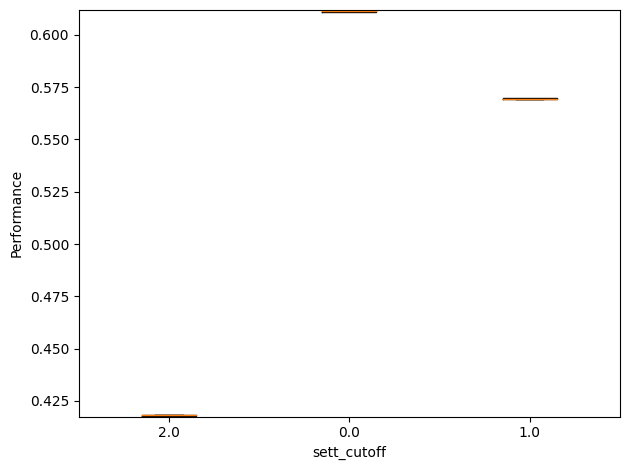

In [39]:
vis.plot_marginal(0)

/home/alberto/.local/share/virtualenvs/fairml-multiverse-qmUEvjAP/lib/python3.8/site-packages/fanova/visualizer.py:123: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  grid_fanova = np.array(grid_fanova)


<module 'matplotlib.pyplot' from '/home/alberto/.local/share/virtualenvs/fairml-multiverse-qmUEvjAP/lib/python3.8/site-packages/matplotlib/pyplot.py'>

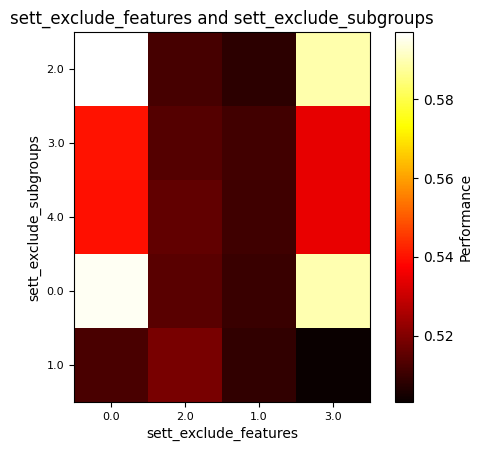

In [40]:
vis.plot_pairwise_marginal(['sett_exclude_features', 'sett_exclude_subgroups'])

## Quantify Importance with Partial Data

In [49]:
from tqdm import tqdm
import psutil
import os

PARTIAL_FANOVA_DIR = ANALYSIS_OUTPUT_DIR / "partial_fanova" / "overall"
PARTIAL_FANOVA_DIR.mkdir(parents=True, exist_ok=True)

N_ITERATIONS = 10
N_JOBS = max(os.cpu_count() - 1, 2)

In [45]:
from fairness_multiverse.analysis import MultiverseFanova
import joblib
from joblib import Parallel, delayed
from tqdm_joblib import tqdm_joblib


def quantify_importance_for_fraction(fraction: float, base_directory = PARTIAL_FANOVA_DIR):
    # Get random subset of the data
    df = df_agg.sample(frac = fraction).reset_index(drop = True)
    data_hash = joblib.hash(df)

    # Create directory for this fraction
    directory = base_directory / f"fraction-{fraction}"
    directory.mkdir(exist_ok = True)

    # Run FANOVA on subset
    partial_fanova = MultiverseFanova(features = df[cols_non_eval], outcome = df[main_fairness_metric])
    PARTIAL_FANOVA_PATH = directory / f"partial-fanova_importance_interactions-majmin-{fraction}-{data_hash}.csv"
    if PARTIAL_FANOVA_PATH.exists():
        print(f"Skipping partial fANOVA for fraction {fraction}; file already exists at {PARTIAL_FANOVA_PATH}")
    else:
        partial_fanova.quantify_importance(save_to = PARTIAL_FANOVA_PATH)

In [46]:
with tqdm_joblib(tqdm(total=N_ITERATIONS)):
    Parallel(n_jobs=N_JOBS)(
        delayed(quantify_importance_for_fraction)(0.01)
        for _ in range(N_ITERATIONS)
    )


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [05:06<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
with tqdm_joblib(tqdm(total=N_ITERATIONS)):
    Parallel(n_jobs=N_JOBS)(
        delayed(quantify_importance_for_fraction)(0.05)
        for _ in range(N_ITERATIONS)
    )


100%|██████████| 10/10 [1:01:16<00:00, 367.64s/it]


In [50]:
with tqdm_joblib(tqdm(total=N_ITERATIONS)):
    Parallel(n_jobs=N_JOBS)(
        delayed(quantify_importance_for_fraction)(0.1)
        for _ in range(N_ITERATIONS)
    )

  0%|          | 0/10 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
with tqdm_joblib(tqdm(total=N_ITERATIONS)):
    Parallel(n_jobs=N_JOBS)(
        delayed(quantify_importance_for_fraction)(0.2)
        for _ in range(N_ITERATIONS)
    )
